# Fase 5 — Motor + mecanismo forward (co-simulacion ODE+PDE)

El motor aporta torque segun su curva, y la velocidad angular $\omega(\theta)$ es **resultado** de la integracion de la EOM del mecanismo (Lagrange):

$$J_{ef}(\theta)\,\ddot\theta + \frac{1}{2}\frac{dJ_{ef}}{d\theta}\,\dot\theta^2 = T_{motor}\cdot N\cdot\eta - F_{PR}\cdot TF - T_{cw} - T_{friccion}$$

**Validaciones esperadas**:
- SPM promedio ±5% del diseno
- Variacion de $\omega$ en el ciclo: ±5-15%
- Balance energetico: error < 5%

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator import params as P
from aib_simulator.coupling import Simulator

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

sim_params = {k: getattr(P, k) for k in dir(P) if not k.startswith('_') and not callable(getattr(P, k))}

sim = Simulator(sim_params, motor_model='linear')
omega_init = 2 * np.pi * 8.0 / 60
sim.initialize(theta_0=0.0, omega_0_crank=omega_init)

n_steps_est = int(15 * 60.0 / 8.0 / P.dt)
print(f"Simulando ~15 ciclos ({n_steps_est} pasos)...")

# Capturar todas las variables relevantes
keys = ['theta', 'omega', 'y_PR', 'F_PR', 'TF', 'T_motor_crank',
        'T_gearbox', 'T_cw', 'F_pump', 'q_inst', 'omega_m', 'T_neto']
results = {k: np.zeros(n_steps_est) for k in keys}
results['u_bottom'] = np.zeros(n_steps_est)
results['T_load'] = np.zeros(n_steps_est)

import time
t0 = time.time()
for step in range(n_steps_est):
    state = sim.step()
    for k in keys:
        results[k][step] = state[k]
    results['u_bottom'][step] = sim.solver.u_curr[-1]
    results['T_load'][step] = state['F_PR'] * state['TF']

elapsed = time.time() - t0
print(f"Completado en {elapsed:.1f}s ({n_steps_est/elapsed:.0f} pasos/s)")

Simulando ~15 ciclos (52325 pasos)...
Completado en 2.2s (23723 pasos/s)


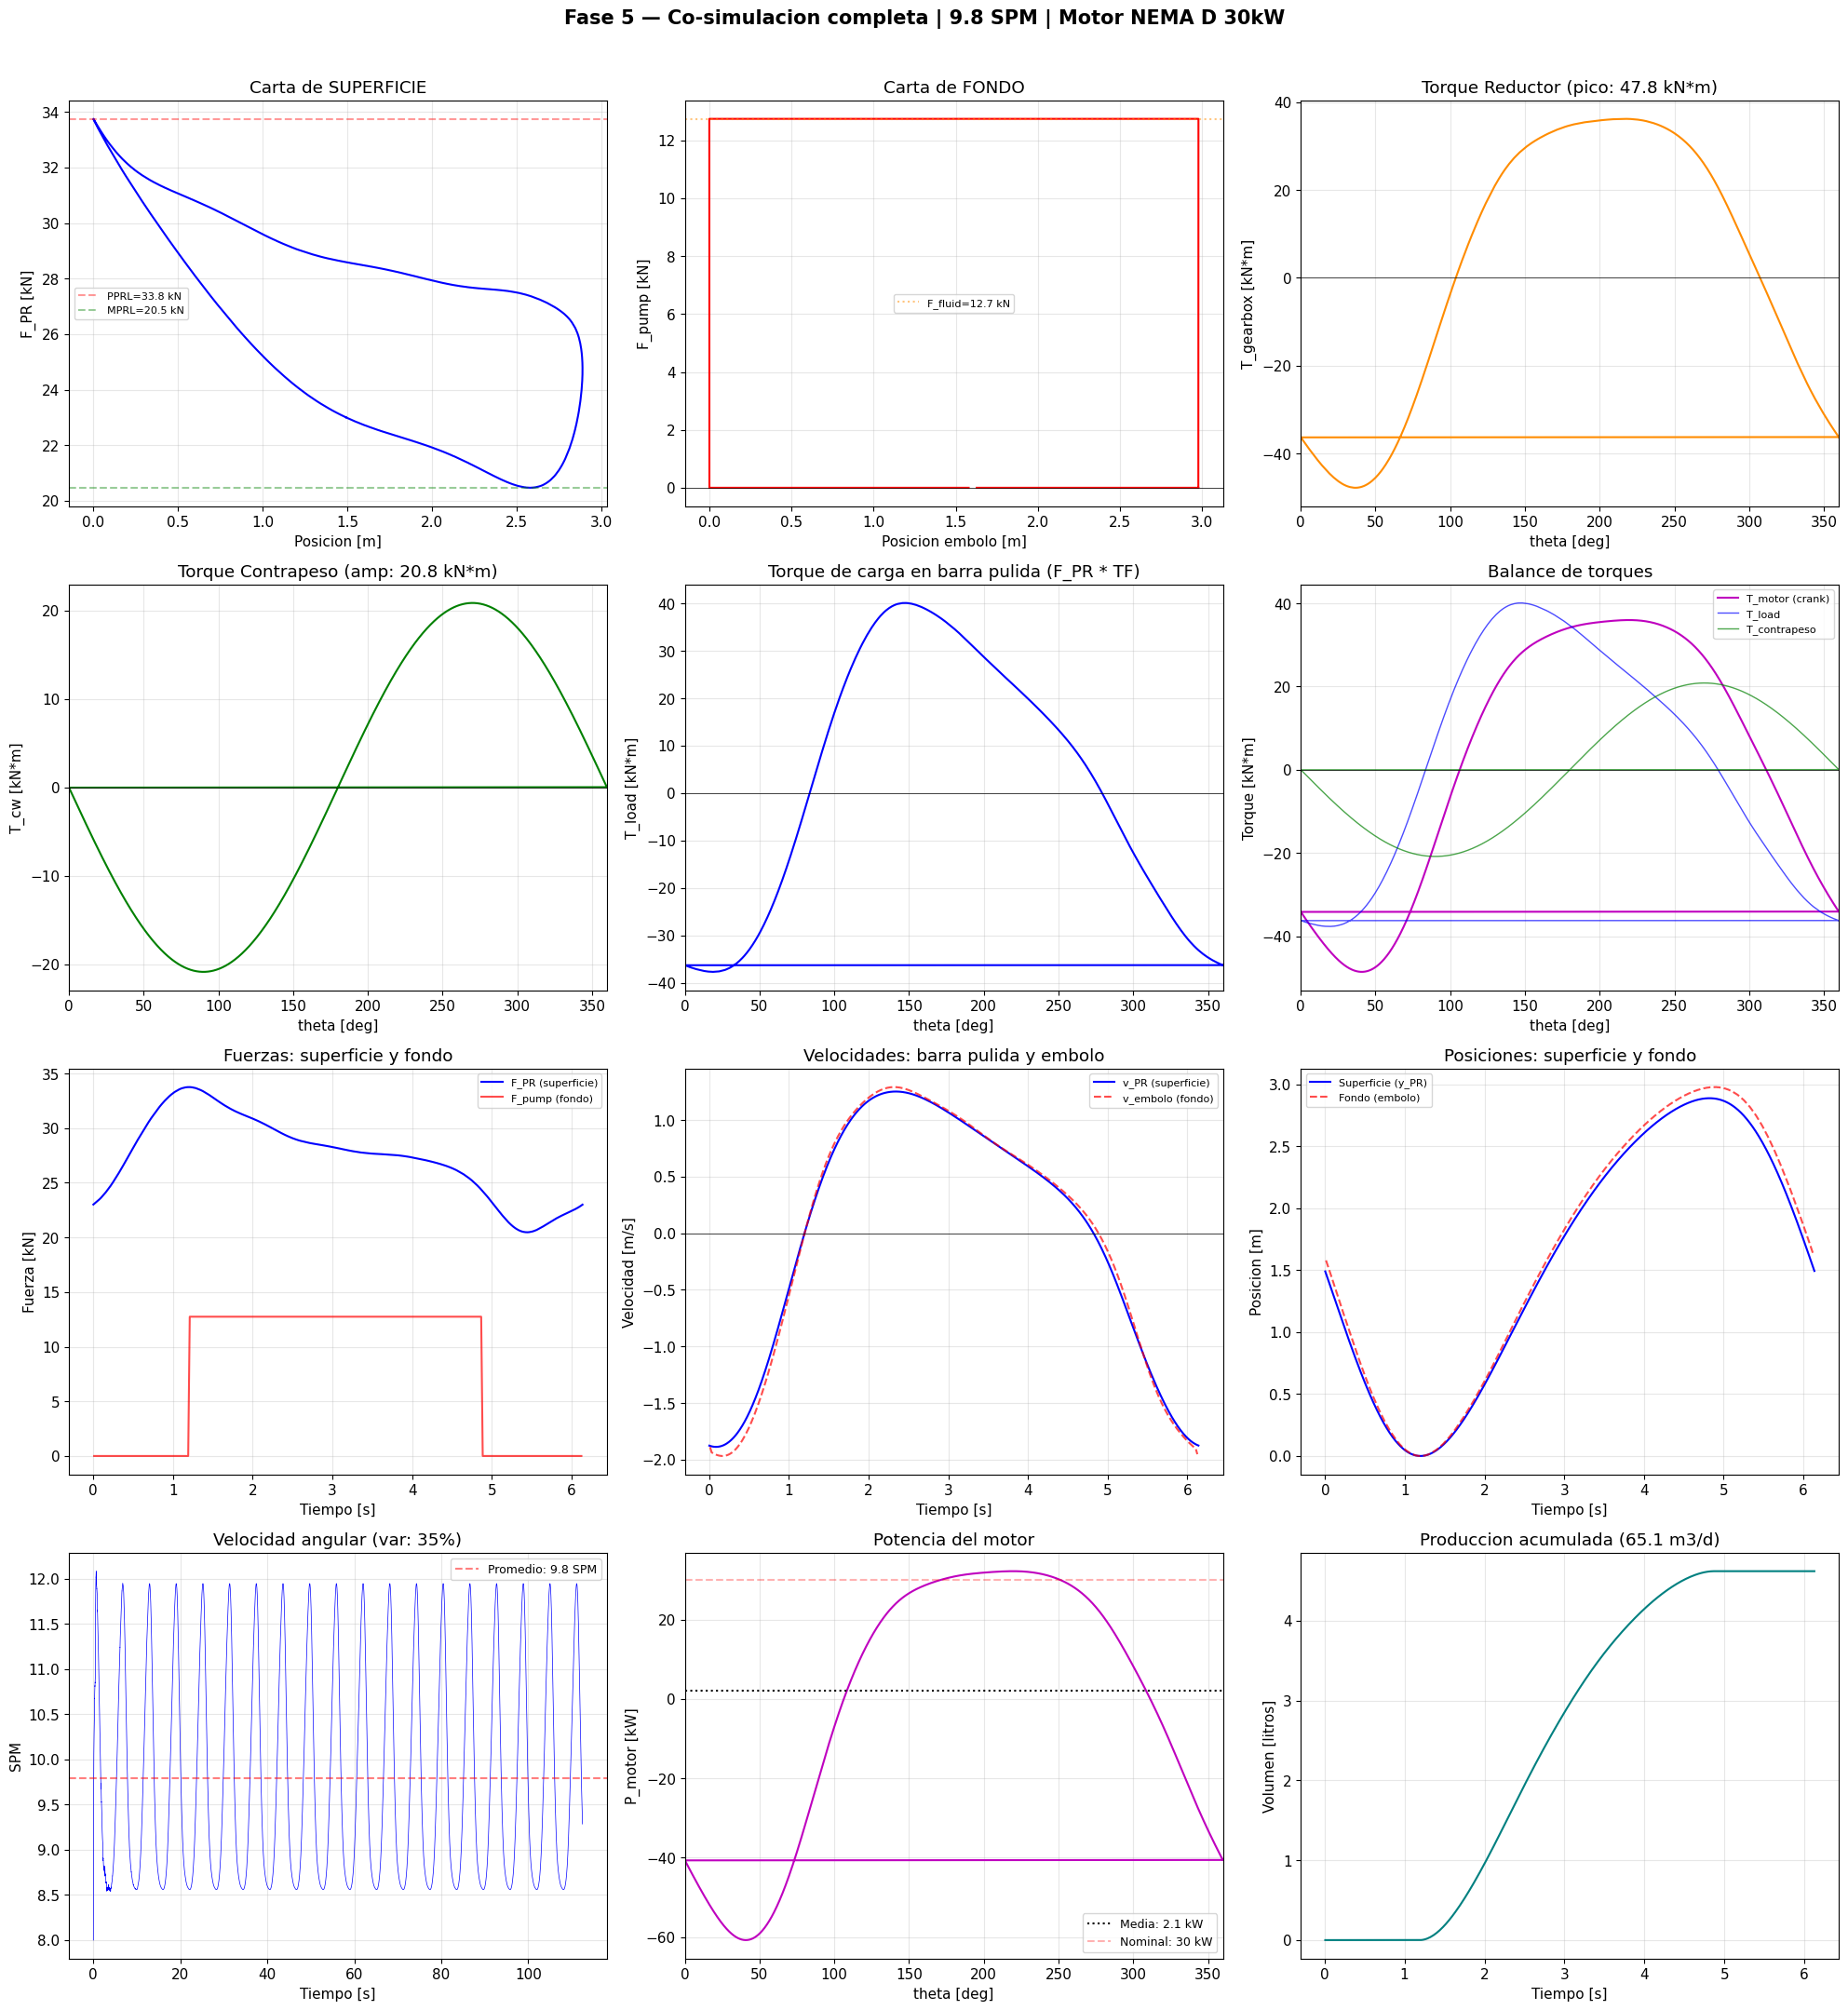

VALIDACIONES — Fase 5: Motor + mecanismo forward

1. SPM promedio: 9.79 (motor con N=150 opera a ~10 SPM)

2. Variacion omega: 34.7% (5-15% con buen contrabalanceo)

3. PPRL = 33.8 kN, MPRL = 20.5 kN

4. Potencia media motor: 2.1 kW (nominal: 30 kW)

5. Torque pico reductor: 47.8 kN*m

6. Torque contrapeso amplitud: 20.8 kN*m

7. Caudal producido: 65.1 m3/d


In [2]:
# ================================================================
# PREPARAR DATOS DEL ULTIMO CICLO
# ================================================================
n_total = n_steps_est
t_arr = np.arange(n_total) * P.dt
omega_design = 2 * np.pi * P.SPM_base / 60

# Identificar ultimo ciclo completo
theta_mod = results['theta'] % (2 * np.pi)
crossings = np.where(np.diff(theta_mod) < -np.pi)[0]
if len(crossings) >= 2:
    i0, i1 = crossings[-2], crossings[-1]
else:
    i0, i1 = n_total - int(60 / 9.5 / P.dt), n_total - 1

sl = slice(i0, i1)
theta_c = results['theta'][sl] % (2 * np.pi)
theta_deg = np.degrees(theta_c)
omega_c = results['omega'][sl]
y_c = results['y_PR'][sl]
F_c = results['F_PR'][sl]
Tgb_c = results['T_gearbox'][sl]
Tmc_c = results['T_motor_crank'][sl]
Tcw_c = results['T_cw'][sl]
Tload_c = results['T_load'][sl]
om_m_c = results['omega_m'][sl]

# Metricas globales
SPM_avg = results['theta'][-1] / (2*np.pi) / (n_total*P.dt/60)
PPRL = np.max(F_c)
MPRL = np.min(F_c)
stroke = np.max(y_c) - np.min(y_c)
omega_mean = np.mean(omega_c)
omega_var = (np.max(omega_c) - np.min(omega_c)) / omega_mean * 100
T_peak = np.max(np.abs(Tgb_c))
P_motor = om_m_c * Tmc_c / P.N_total
P_avg = np.mean(P_motor)

# Reconstruir senales de fondo desde posicion del embolo
u_bot_c = results['u_bottom'][sl]
M = max(1, int(0.02 / P.dt))
n_sub = len(u_bot_c) // M
u_sub = np.array([np.mean(u_bot_c[j*M:(j+1)*M]) for j in range(n_sub)])
t_sub = np.array([(j + 0.5) * M * P.dt for j in range(n_sub)])
pos_emb = -(u_sub - np.max(u_sub))
v_emb = -np.gradient(u_sub, M * P.dt)  # positivo = sube

F_fluid_val = (P.P_wh + P.rho_f*P.g*P.L_bomba - P.P_ann - P.rho_f*P.g*(P.L_bomba - P.h_din_0)) * P.pump_A
F_pump_disp = np.where(v_emb > 0, F_fluid_val, 0.0)
q_disp = P.pump_A * np.maximum(0, v_emb)
q_avg_m3d = np.mean(q_disp) * 86400

# Velocidad de la barra pulida (derivada de y_PR)
v_PR = np.gradient(y_c, P.dt)

# ================================================================
# DASHBOARD: 4 filas x 3 columnas (12 graficos)
# ================================================================
fig, axes = plt.subplots(4, 3, figsize=(20, 22))

# ===================== FILA 1: CARTAS + TORQUE REDUCTOR =====================

# 1,1 — Carta de superficie
ax = axes[0, 0]
y_norm = y_c - np.min(y_c)
ax.plot(y_norm, F_c / 1e3, 'b-', linewidth=1.5)
ax.axhline(PPRL/1e3, color='r', ls='--', alpha=0.4, label=f'PPRL={PPRL/1e3:.1f} kN')
ax.axhline(MPRL/1e3, color='g', ls='--', alpha=0.4, label=f'MPRL={MPRL/1e3:.1f} kN')
ax.set_xlabel('Posicion [m]')
ax.set_ylabel('F_PR [kN]')
ax.set_title('Carta de SUPERFICIE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 1,2 — Carta de fondo (reconstruida)
ax = axes[0, 1]
ax.plot(pos_emb, F_pump_disp / 1e3, 'r-', linewidth=1.5)
ax.axhline(F_fluid_val/1e3, color='darkorange', ls=':', alpha=0.5,
           label=f'F_fluid={F_fluid_val/1e3:.1f} kN')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Posicion embolo [m]')
ax.set_ylabel('F_pump [kN]')
ax.set_title('Carta de FONDO')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 1,3 — Torque en el reductor
ax = axes[0, 2]
ax.plot(theta_deg, Tgb_c/1e3, 'darkorange', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('theta [deg]')
ax.set_ylabel('T_gearbox [kN*m]')
ax.set_title(f'Torque Reductor (pico: {T_peak/1e3:.1f} kN*m)')
ax.set_xlim(0, 360)
ax.grid(True, alpha=0.3)

# ===================== FILA 2: TORQUES =====================

# 2,1 — Torque del contrapeso
ax = axes[1, 0]
ax.plot(theta_deg, Tcw_c/1e3, 'green', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('theta [deg]')
ax.set_ylabel('T_cw [kN*m]')
ax.set_title(f'Torque Contrapeso (amp: {np.max(np.abs(Tcw_c))/1e3:.1f} kN*m)')
ax.set_xlim(0, 360)
ax.grid(True, alpha=0.3)

# 2,2 — Torque de carga (F_PR * TF)
ax = axes[1, 1]
ax.plot(theta_deg, Tload_c/1e3, 'b-', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('theta [deg]')
ax.set_ylabel('T_load [kN*m]')
ax.set_title('Torque de carga en barra pulida (F_PR * TF)')
ax.set_xlim(0, 360)
ax.grid(True, alpha=0.3)

# 2,3 — Torque motor vs carga vs contrapeso (superpuestos)
ax = axes[1, 2]
ax.plot(theta_deg, Tmc_c/1e3, 'm-', linewidth=1.5, label='T_motor (crank)')
ax.plot(theta_deg, Tload_c/1e3, 'b-', linewidth=1, alpha=0.7, label='T_load')
ax.plot(theta_deg, Tcw_c/1e3, 'g-', linewidth=1, alpha=0.7, label='T_contrapeso')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('theta [deg]')
ax.set_ylabel('Torque [kN*m]')
ax.set_title('Balance de torques')
ax.legend(fontsize=8)
ax.set_xlim(0, 360)
ax.grid(True, alpha=0.3)

# ===================== FILA 3: FUERZAS Y VELOCIDADES =====================

# 3,1 — Fuerzas: superficie y fondo vs tiempo
ax = axes[2, 0]
t_cycle = np.arange(i1 - i0) * P.dt
ax.plot(t_cycle, F_c/1e3, 'b-', linewidth=1.5, label='F_PR (superficie)')
ax.plot(t_sub, F_pump_disp/1e3, 'r-', linewidth=1.5, alpha=0.7, label='F_pump (fondo)')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Fuerza [kN]')
ax.set_title('Fuerzas: superficie y fondo')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3,2 — Velocidades: barra pulida y embolo vs tiempo
ax = axes[2, 1]
ax.plot(t_cycle, v_PR, 'b-', linewidth=1.5, label='v_PR (superficie)')
ax.plot(t_sub, v_emb, 'r--', linewidth=1.5, alpha=0.7, label='v_embolo (fondo)')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Velocidad [m/s]')
ax.set_title('Velocidades: barra pulida y embolo')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3,3 — Posiciones: superficie y fondo vs tiempo
ax = axes[2, 2]
ax.plot(t_cycle, y_norm, 'b-', linewidth=1.5, label='Superficie (y_PR)')
ax.plot(t_sub, pos_emb, 'r--', linewidth=1.5, alpha=0.7, label='Fondo (embolo)')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Posicion [m]')
ax.set_title('Posiciones: superficie y fondo')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ===================== FILA 4: MOTOR Y PRODUCCION =====================

# 4,1 — omega(t) todo el run
ax = axes[3, 0]
ax.plot(t_arr, results['omega']*60/(2*np.pi), 'b-', linewidth=0.5)
ax.axhline(SPM_avg, color='r', ls='--', alpha=0.5, label=f'Promedio: {SPM_avg:.1f} SPM')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('SPM')
ax.set_title(f'Velocidad angular (var: {omega_var:.0f}%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 4,2 — Potencia motor
ax = axes[3, 1]
ax.plot(theta_deg, P_motor/1e3, 'm-', linewidth=1.5)
ax.axhline(P_avg/1e3, color='k', ls=':', label=f'Media: {P_avg/1e3:.1f} kW')
ax.axhline(P.P_nom/1e3, color='r', ls='--', alpha=0.3, label=f'Nominal: {P.P_nom/1e3:.0f} kW')
ax.set_xlabel('theta [deg]')
ax.set_ylabel('P_motor [kW]')
ax.set_title('Potencia del motor')
ax.legend(fontsize=9)
ax.set_xlim(0, 360)
ax.grid(True, alpha=0.3)

# 4,3 — Caudal acumulado (reconstruido)
ax = axes[3, 2]
q_cumul = np.cumsum(q_disp) * M * P.dt
ax.plot(t_sub, q_cumul * 1e3, 'teal', linewidth=1.5)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Volumen [litros]')
ax.set_title(f'Produccion acumulada ({q_avg_m3d:.1f} m3/d)')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Fase 5 — Co-simulacion completa | {SPM_avg:.1f} SPM | Motor NEMA D 30kW',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ================================================================
# VALIDACIONES
# ================================================================
print("=" * 60)
print("VALIDACIONES — Fase 5: Motor + mecanismo forward")
print("=" * 60)
print(f"\n1. SPM promedio: {SPM_avg:.2f} (motor con N=150 opera a ~{SPM_avg:.0f} SPM)")
print(f"\n2. Variacion omega: {omega_var:.1f}% (5-15% con buen contrabalanceo)")
print(f"\n3. PPRL = {PPRL/1e3:.1f} kN, MPRL = {MPRL/1e3:.1f} kN")
print(f"\n4. Potencia media motor: {P_avg/1e3:.1f} kW (nominal: {P.P_nom/1e3:.0f} kW)")
print(f"\n5. Torque pico reductor: {T_peak/1e3:.1f} kN*m")
print(f"\n6. Torque contrapeso amplitud: {np.max(np.abs(Tcw_c))/1e3:.1f} kN*m")
print(f"\n7. Caudal producido: {q_avg_m3d:.1f} m3/d")